# Day 1 — ช่วงบ่าย: ลงมือปฏิบัติ Deep Learning ด้วย Keras

โน้ตบุ๊กนี้เป็นแบบ **step-by-step โค้ดครบทุกเซลล์** รันตามลำดับจากบนลงล่างได้เลย
แต่ละเซลล์มีคำอธิบายกำกับว่าทำอะไรและทำไม

**เนื้อหา 4 ส่วน**
1. **MLP** บน Fashion-MNIST — neural network แรกและ workflow การฝึก
2. **CNN** บนข้อมูลเดียวกัน — เทียบผลกับ MLP
3. **Transfer learning** บนรูปอาหาร — ใช้โมเดลสำเร็จรูป
4. **สรุปและเปรียบเทียบ** ผลทั้งหมด

> **ก่อนเริ่ม:** เปิด GPU ที่เมนู `Runtime > Change runtime type > Hardware accelerator > GPU`
> โดยเฉพาะส่วนที่ 3 ที่ใช้โมเดลใหญ่


## ขั้นเตรียม — โหลดไลบรารีและตรวจสภาพแวดล้อม

รันเซลล์นี้ก่อนเป็นอันดับแรก เพื่อโหลดเครื่องมือทั้งหมดและเช็กว่ามี GPU หรือไม่


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", "พร้อมใช้งาน ✓" if gpus else "ไม่พบ — ส่วนที่ 3 จะช้า ควรเปิด GPU ก่อน")

TensorFlow version: 2.21.0
GPU: ไม่พบ — ส่วนที่ 3 จะช้า ควรเปิด GPU ก่อน


---
# ส่วนที่ 1 — MLP บน Fashion-MNIST

Fashion-MNIST คือชุดภาพเสื้อผ้าขาวดำ ขนาด 28×28 พิกเซล 10 ประเภท
เราจะสร้าง neural network แรกเพื่อจำแนกภาพเหล่านี้


### ขั้นที่ 1.1 — โหลดข้อมูล

`load_data()` ดาวน์โหลดชุดข้อมูลครั้งแรกครั้งเดียว แล้วเก็บไว้ในเครื่อง
คืนค่ามาเป็นสองคู่: ชุดฝึก (train) และชุดทดสอบ (test)


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# ชื่อประเภทของแต่ละหมายเลข 0-9
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("รูปฝึก (train):", x_train.shape)   # (60000, 28, 28)
print("ป้ายฝึก:", y_train.shape)          # (60000,)
print("รูปทดสอบ (test):", x_test.shape)   # (10000, 28, 28)
print("ค่าพิกเซล: ต่ำสุด =", x_train.min(), " สูงสุด =", x_train.max())

รูปฝึก (train): (60000, 28, 28)
ป้ายฝึก: (60000,)
รูปทดสอบ (test): (10000, 28, 28)
ค่าพิกเซล: ต่ำสุด = 0  สูงสุด = 255


### ขั้นที่ 1.2 — ดูภาพจริงก่อนเสมอ

ก่อนฝึกโมเดล ควรดูข้อมูลจริงเพื่อยืนยันว่าภาพกับป้ายตรงกัน


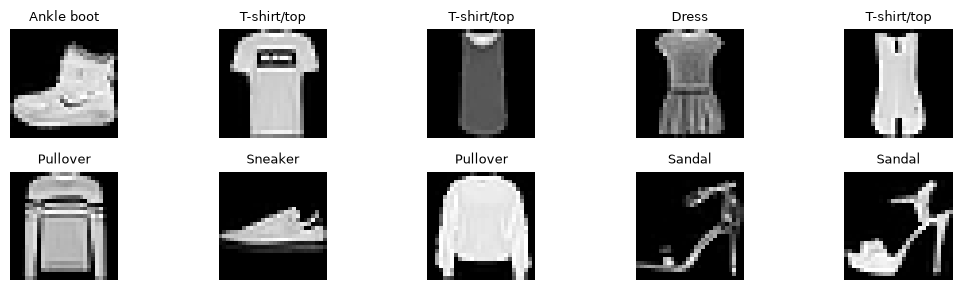

In [3]:
plt.figure(figsize=(11, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

### ขั้นที่ 1.3 — เตรียมข้อมูล (Normalization)

ค่าพิกเซลเดิมอยู่ในช่วง 0–255 เราหารด้วย 255 เพื่อปรับให้อยู่ในช่วง 0–1
ช่วยให้การฝึก (gradient descent) ทำงานได้ราบรื่นและเสถียรขึ้น


In [4]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

print("หลังปรับค่า: ต่ำสุด =", x_train.min(), " สูงสุด =", x_train.max())

หลังปรับค่า: ต่ำสุด = 0.0  สูงสุด = 1.0


### ขั้นที่ 1.4 — สร้างโมเดล MLP (ขั้นที่ 1 ของ 3)

จำ workflow 3 ขั้นจากช่วงเช้า: **สร้าง → compile → fit**

โครงสร้าง:
- `Flatten` คลี่ภาพ 28×28 เป็นเวกเตอร์ 784 ค่า
- `Dense(128, relu)` ชั้นซ่อน 128 หน่วย
- `Dense(10, softmax)` ชั้นสุดท้าย 10 หน่วย (เท่าจำนวนคลาส)


In [5]:
mlp = keras.Sequential([
    layers.Input((28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**อ่าน summary:** ลองสังเกตคอลัมน์ Param # — ชั้น Dense แรกมี (784 × 128) + 128 = 100,480 พารามิเตอร์
รวมทั้งโมเดลประมาณ 101,770 จำเลขนี้ไว้เทียบกับ CNN ในส่วนถัดไป

### ขั้นที่ 1.5 — compile (ขั้นที่ 2 ของ 3)

บอกโมเดลว่าจะฝึกอย่างไร:
- `optimizer='adam'` วิธีปรับ weight มาตรฐานที่แนะนำ
- `loss='sparse_categorical_crossentropy'` ใช้ค่านี้เพราะป้าย y เป็นเลขจำนวนเต็ม (0–9)
- `metrics=['accuracy']` ค่าที่เราอยากติดตาม


In [6]:
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print("compile เรียบร้อย พร้อมฝึก")

compile เรียบร้อย พร้อมฝึก


### ขั้นที่ 1.6 — fit: สั่งฝึก (ขั้นที่ 3 ของ 3)

- `epochs=10` ดูข้อมูลครบทั้งชุด 10 รอบ
- `validation_split=0.1` กันข้อมูล 10% ไว้ตรวจสอบระหว่างฝึก (ดู overfitting)

ระหว่างฝึกจะเห็นแถบแสดง loss และ accuracy ของทั้ง train และ validation ในแต่ละ epoch


In [7]:
history_mlp = mlp.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 770us/step - accuracy: 0.8207 - loss: 0.5115 - val_accuracy: 0.8465 - val_loss: 0.4287
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.8618 - loss: 0.3817 - val_accuracy: 0.8662 - val_loss: 0.3756
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.8755 - loss: 0.3427 - val_accuracy: 0.8743 - val_loss: 0.3518
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.8832 - loss: 0.3157 - val_accuracy: 0.8698 - val_loss: 0.3513
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step - accuracy: 0.8896 - loss: 0.2974 - val_accuracy: 0.8760 - val_loss: 0.3379
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - accuracy: 0.8959 - loss: 0.2800 - val_accuracy: 0.8778 - val_loss: 0.3365
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 929us/step - accuracy: 0.9008 - loss: 0.2683 - val_accuracy: 0.8850 - val_loss: 0.3205
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 734us/step - accuracy: 0.9050 -

### ขั้นที่ 1.7 — อ่าน loss curve

ฟังก์ชันนี้พล็อตเส้น train เทียบ validation เราจะใช้ซ้ำหลายครั้ง
สังเกตว่าสองเส้นเริ่มถ่างออกเมื่อไร นั่นคือจุดที่เริ่ม overfitting


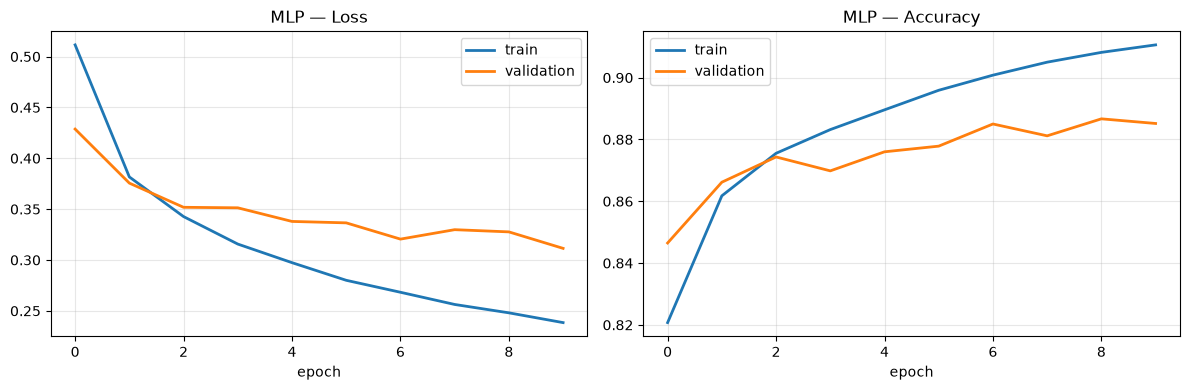

In [8]:
def plot_history(history, title=""):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train', linewidth=2)
    ax[0].plot(h['val_loss'], label='validation', linewidth=2)
    ax[0].set_title(f'{title} — Loss'); ax[0].set_xlabel('epoch')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(h['accuracy'], label='train', linewidth=2)
    ax[1].plot(h['val_accuracy'], label='validation', linewidth=2)
    ax[1].set_title(f'{title} — Accuracy'); ax[1].set_xlabel('epoch')
    ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP")

### ขั้นที่ 1.8 — วัดผลบน test set

`evaluate` วัดผลบนข้อมูลที่โมเดลไม่เคยเห็นระหว่างฝึก — เป็นความสามารถจริงของโมเดล
เราเก็บค่าไว้ในตัวแปรเพื่อนำไปเทียบกับ CNN


In [9]:
mlp_loss, mlp_acc = mlp.evaluate(x_test, y_test, verbose=0)
mlp_params = mlp.count_params()

print(f"MLP test accuracy : {mlp_acc:.4f}")
print(f"MLP parameters    : {mlp_params:,}")

MLP test accuracy : 0.8804
MLP parameters    : 101,770


---
# ส่วนที่ 2 — CNN บน Fashion-MNIST

ตอนนี้เราแก้โจทย์เดียวกันด้วย CNN ซึ่งออกแบบมาสำหรับข้อมูลภาพโดยเฉพาะ แล้วเทียบผล


### ขั้นที่ 2.1 — เพิ่มมิติช่องสี

CNN ต้องการข้อมูลรูปแบบ (สูง, กว้าง, ช่องสี) ภาพขาวดำมี 1 ช่องสี
เราจึงเพิ่มมิติสุดท้ายจาก (28, 28) เป็น (28, 28, 1)


In [10]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn  = x_test[..., np.newaxis]

print("รูปสำหรับ CNN:", x_train_cnn.shape)   # (60000, 28, 28, 1)

รูปสำหรับ CNN: (60000, 28, 28, 1)


### ขั้นที่ 2.2 — สร้างโมเดล CNN

โครงสร้างมาตรฐาน: ทำซ้ำเป็นคู่ (Conv → Pool) แล้วปิดท้ายด้วย Flatten → Dense
สังเกตว่าจำนวน filter เพิ่มจาก 32 เป็น 64 เมื่อชั้นลึกขึ้น


In [11]:
cnn = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

**อ่าน summary:** ดูคอลัมน์ Output Shape จะเห็นภาพหดทีละชั้น
28 → 26 (Conv ตัดขอบ) → 13 (Pool ย่อครึ่ง) → 11 (Conv) → 5 (Pool)
ซึ่งตรงกับเรื่อง padding และ stride ที่เรียนตอนเช้า

### ขั้นที่ 2.3 — compile และ fit

ขั้นตอนเหมือน MLP ทุกประการ เปลี่ยนแค่ข้อมูลเป็น `x_train_cnn`
นี่คือบทเรียนสำคัญ: workflow 3 ขั้นใช้ได้กับทุกโมเดล เปลี่ยนแค่ส่วนโครงสร้าง


In [12]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8260 - loss: 0.4773 - val_accuracy: 0.8778 - val_loss: 0.3468
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8820 - loss: 0.3218 - val_accuracy: 0.8823 - val_loss: 0.3261
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8992 - loss: 0.2748 - val_accuracy: 0.9018 - val_loss: 0.2717
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9093 - loss: 0.2441 - val_accuracy: 0.9025 - val_loss: 0.2587
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9180 - loss: 0.2190 - val_accuracy: 0.9107 - val_loss: 0.2491
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9272 - loss: 0.1977 - val_accuracy: 0.9120 - val_loss: 0.2454
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9344 - loss: 0.1776 - val_accuracy: 0.9140 - val_loss: 0.2424
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9398 - loss: 0.1612 - 

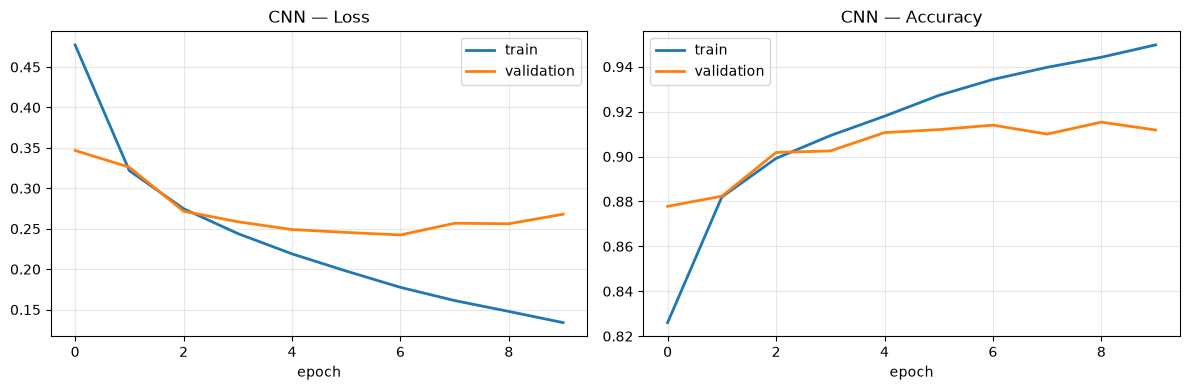

In [13]:
plot_history(history_cnn, "CNN")

### ขั้นที่ 2.4 — วัดผลและเทียบกับ MLP

In [14]:
cnn_loss, cnn_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)
cnn_params = cnn.count_params()

print(f"{'โมเดล':<8}{'test accuracy':<18}{'parameters'}")
print("-" * 40)
print(f"{'MLP':<8}{mlp_acc:<18.4f}{mlp_params:,}")
print(f"{'CNN':<8}{cnn_acc:<18.4f}{cnn_params:,}")

โมเดล   test accuracy     parameters
----------------------------------------
MLP     0.8804            101,770
CNN     0.9063            121,930


**จุดสำคัญ:** โดยทั่วไป CNN จะแม่นกว่า ทั้งที่จำนวนพารามิเตอร์ไม่ได้มากกว่ากันมาก
เพราะ Conv layer ใช้ประโยชน์จากโครงสร้างเชิงพื้นที่ของภาพ ซึ่งเป็นหัวใจของช่วงเช้า

### ขั้นที่ 2.5 — Confusion matrix

ดูว่าโมเดลสับสนคลาสไหนกับคลาสไหน


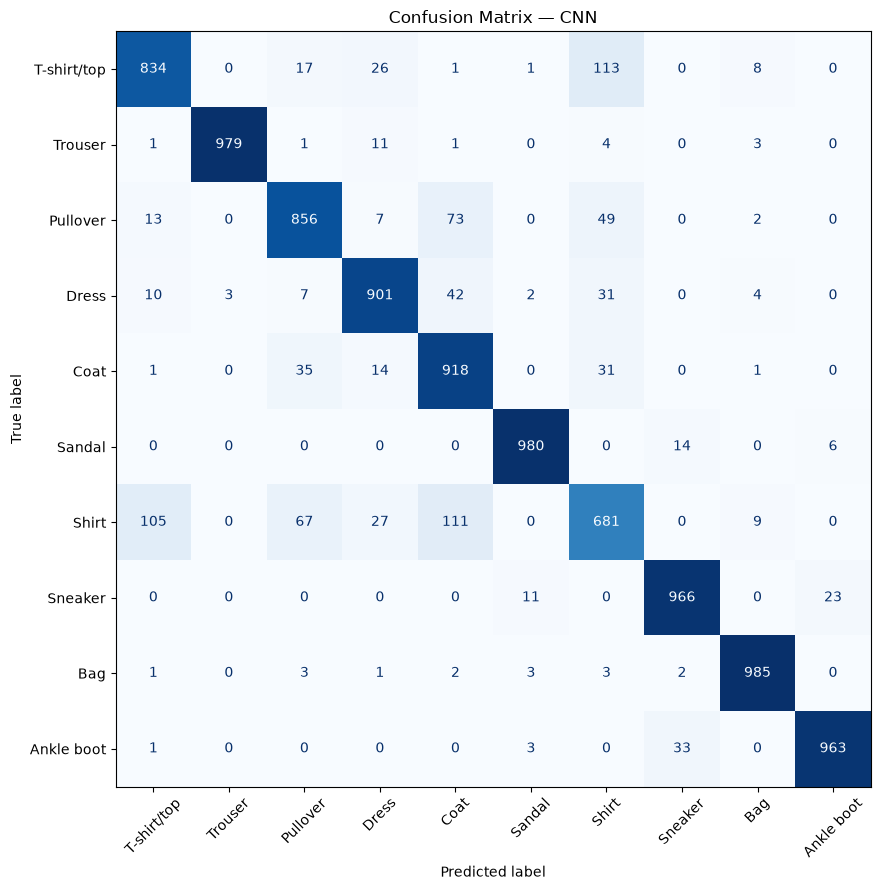

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ทำนายคลาสของทุกภาพใน test set
y_pred = cnn.predict(x_test_cnn, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix — CNN")
plt.tight_layout()
plt.show()

**ลองสังเกต:** คลาสที่มักถูกสับสนคือ Shirt / Pullover / Coat / T-shirt
เพราะรูปทรงคล้ายกันมากในภาพขาวดำขนาดเล็ก

---
# ส่วนที่ 3 — Transfer Learning บนรูปอาหาร

เปลี่ยนจากภาพขาวดำเล็ก ๆ มาเป็นภาพสีจริง และใช้โมเดลสำเร็จรูปที่ฝึกมาแล้วจาก ImageNet
ชุดข้อมูลคือ pizza / steak / sushi เพียง 3 คลาส คลาสละไม่กี่ร้อยภาพ

> ส่วนนี้ควรเปิด GPU เพื่อความเร็ว


### ขั้นที่ 3.1 — ดาวน์โหลดชุดข้อมูล

`get_file` ดาวน์โหลดไฟล์ zip แล้วแตกไฟล์ให้อัตโนมัติ


In [16]:
import pathlib

url = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
path = keras.utils.get_file("pizza_steak_sushi.zip", origin=url, extract=True)
data_dir = pathlib.Path(path)

print("โฟลเดอร์ข้อมูล:", data_dir)
classes = sorted([p.name for p in (data_dir / 'train').iterdir() if p.is_dir()])
print("คลาส:", classes)

โฟลเดอร์ข้อมูล: /Users/pasunimsuwan/.keras/datasets/pizza_steak_sushi_extracted
คลาส: ['pizza', 'steak', 'sushi']


### ขั้นที่ 3.2 — สร้าง data pipeline

`image_dataset_from_directory` อ่านภาพจากโฟลเดอร์ โดยใช้ชื่อโฟลเดอร์ย่อยเป็นป้ายคลาสอัตโนมัติ
ปรับขนาดทุกภาพเป็น 224×224 ให้ตรงกับที่โมเดลสำเร็จรูปคาดหวัง


In [17]:
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    data_dir / 'train',
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode='int',
)
test_ds = keras.utils.image_dataset_from_directory(
    data_dir / 'test',
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode='int',
)

class_names_food = train_ds.class_names
print("คลาส:", class_names_food)

Found 225 files belonging to 3 classes.
Found 75 files belonging to 3 classes.
คลาส: ['pizza', 'steak', 'sushi']


### ขั้นที่ 3.3 — ดูตัวอย่างภาพหนึ่ง batch

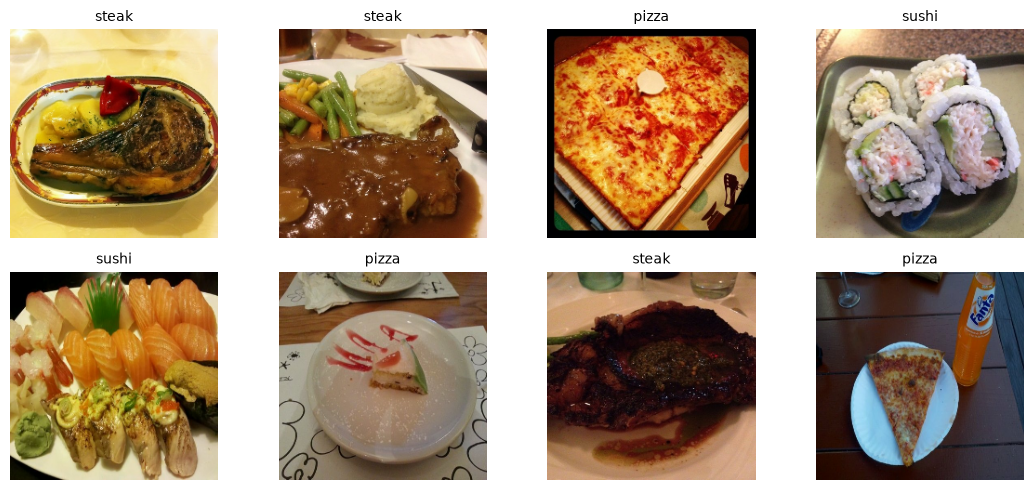

In [18]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(11, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names_food[labels[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### ขั้นที่ 3.4 — เพิ่มความเร็วด้วย prefetch

`cache` เก็บข้อมูลไว้ในหน่วยความจำหลังอ่านรอบแรก และ `prefetch` เตรียมข้อมูล batch ถัดไป
ล่วงหน้าระหว่างที่ GPU กำลังฝึก batch ปัจจุบัน ทำให้ฝึกเร็วขึ้น


In [19]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)
print("เตรียม pipeline เรียบร้อย")

เตรียม pipeline เรียบร้อย


### ขั้นที่ 3.5 — Feature extraction

ขั้นตอน:
1. โหลด EfficientNetV2B0 แบบ `include_top=False` (ตัดชั้นจำแนกเดิมของ ImageNet ออก)
2. `base.trainable = False` — **ตรึง** พารามิเตอร์เดิมไว้ทั้งหมด
3. ต่อชั้นจำแนกของเราเองด้านบน

> EfficientNet มี normalization อยู่ภายในแล้ว จึงป้อนค่าพิกเซล 0–255 ได้โดยตรง ไม่ต้องหาร 255


In [20]:
base = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
)
base.trainable = False   # ตรึงโมเดลเดิม

model = keras.Sequential([
    layers.Input((224, 224, 3)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(class_names_food), activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,923,155 (22.60 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

**อ่าน summary:** สังเกตว่า Trainable params มีน้อยมาก (แค่ชั้น Dense ที่เราเพิ่ม)
ส่วน Non-trainable params คือโมเดลเดิมที่ถูกตรึงไว้ทั้งหมด — นี่คือเหตุผลที่ฝึกได้เร็ว

### ขั้นที่ 3.6 — ฝึก feature extraction

ฝึกเพียง 5 epoch เพราะเราปรับเฉพาะชั้นบนสุด สังเกตว่าความแม่นสูงตั้งแต่ epoch แรก ๆ
ทั้งที่ข้อมูลน้อยมาก


Epoch 1/5


/Users/pasunimsuwan/Desktop/DPU/DT-509/W1/Workshop/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step - accuracy: 0.6044 - loss: 0.9253 - val_accuracy: 0.8000 - val_loss: 0.6529
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.8756 - loss: 0.5672 - val_accuracy: 0.8533 - val_loss: 0.4542
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.9244 - loss: 0.4153 - val_accuracy: 0.8800 - val_loss: 0.3752
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.9467 - loss: 0.3122 - val_accuracy: 0.8800 - val_loss: 0.3395
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.9467 - loss: 0.2659 - val_accuracy: 0.8667 - val_loss: 0.3178


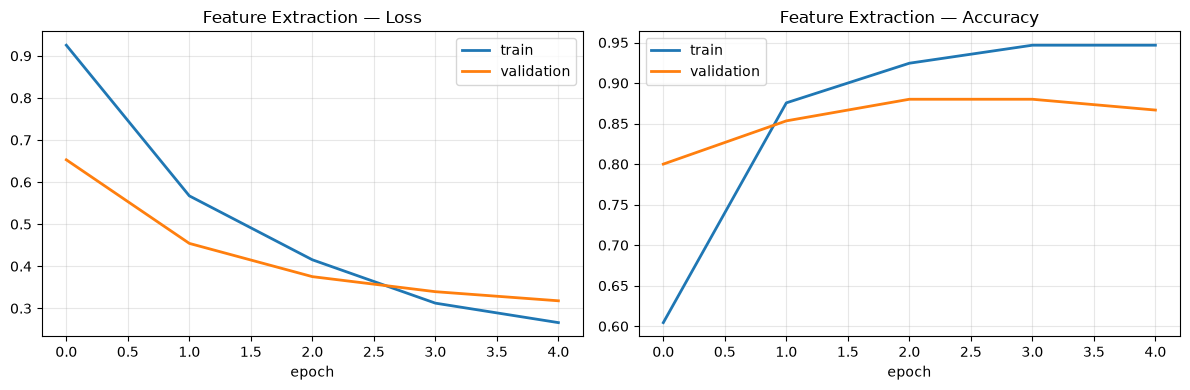

In [21]:
history_fe = model.fit(train_ds, validation_data=test_ds, epochs=5)
plot_history(history_fe, "Feature Extraction")

### ขั้นที่ 3.7 — Fine-tuning

ปลดล็อกชั้นท้าย ๆ ของโมเดลเดิมให้ปรับตามข้อมูลอาหารได้
**สำคัญ:** ต้องใช้ learning rate ต่ำมาก (1e-5) เพื่อไม่ให้ความรู้เดิมที่ดีอยู่แล้วเสียหาย


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step - accuracy: 0.8533 - loss: 0.4639 - val_accuracy: 0.8667 - val_loss: 0.3423
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.8711 - loss: 0.4476 - val_accuracy: 0.8667 - val_loss: 0.3677
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.8756 - loss: 0.4222 - val_accuracy: 0.8667 - val_loss: 0.3801
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.9111 - loss: 0.4278 - val_accuracy: 0.8667 - val_loss: 0.3862
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.8933 - loss: 0.4047 - val_accuracy: 0.8667 - val_loss: 0.3884


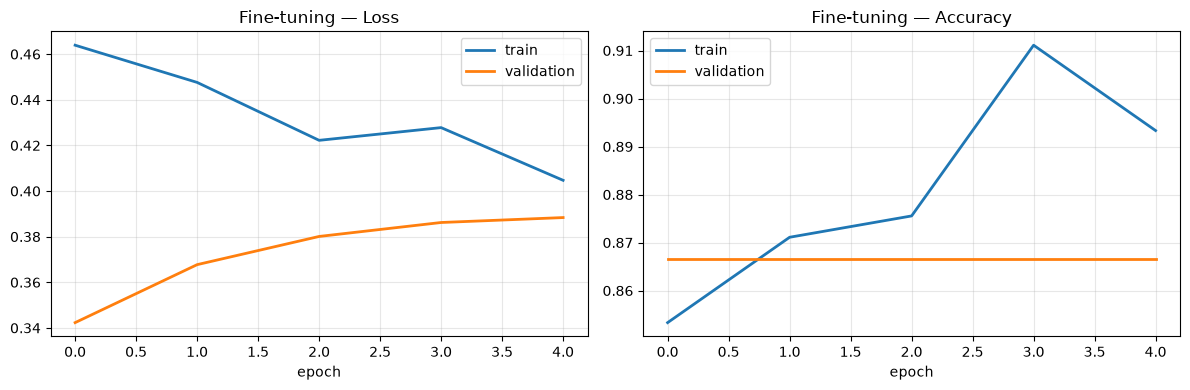

In [22]:
base.trainable = True

# ตรึงทุกชั้น ยกเว้น 20 ชั้นท้าย
for layer in base.layers[:-20]:
    layer.trainable = False

# compile ใหม่ด้วย learning rate ต่ำมาก (จำเป็นหลังเปลี่ยน trainable)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_ft = model.fit(train_ds, validation_data=test_ds, epochs=5)
plot_history(history_ft, "Fine-tuning")

### ขั้นที่ 3.8 — วัดผล transfer learning

In [23]:
fe_acc = max(history_fe.history['val_accuracy'])
ft_acc = max(history_ft.history['val_accuracy'])

print(f"Feature extraction — validation accuracy สูงสุด : {fe_acc:.4f}")
print(f"Fine-tuning        — validation accuracy สูงสุด : {ft_acc:.4f}")

Feature extraction — validation accuracy สูงสุด : 0.8800
Fine-tuning        — validation accuracy สูงสุด : 0.8667


---
# ส่วนที่ 4 — สรุปและเปรียบเทียบผล

รวมผลทั้งหมดของวันนี้ไว้ในตารางเดียว


In [24]:
print(f"{'วิธี':<28}{'accuracy':<12}{'parameters':<14}")
print("=" * 54)
print(f"{'MLP (Fashion-MNIST)':<28}{mlp_acc:<12.4f}{mlp_params:<14,}")
print(f"{'CNN (Fashion-MNIST)':<28}{cnn_acc:<12.4f}{cnn_params:<14,}")
print(f"{'Feature extraction (อาหาร)':<28}{fe_acc:<12.4f}{'-':<14}")
print(f"{'Fine-tuning (อาหาร)':<28}{ft_acc:<12.4f}{'-':<14}")

วิธี                        accuracy    parameters    
MLP (Fashion-MNIST)         0.8804      101,770       
CNN (Fashion-MNIST)         0.9063      121,930       
Feature extraction (อาหาร)  0.8800      -             
Fine-tuning (อาหาร)         0.8667      -             


**ข้อสังเกตที่คาดว่าจะได้เห็น:**

1. CNN แม่นกว่า MLP บนงานเดียวกัน ทั้งที่พารามิเตอร์พอ ๆ กัน
2. Transfer learning ให้ความแม่นสูงมากบนข้อมูลอาหารที่มีน้อย เพราะยืมความรู้จาก ImageNet มา
3. Fine-tuning มักให้ผลดีกว่า feature extraction เล็กน้อย

**สรุปบทเรียนของวันนี้:** workflow การฝึกโมเดลคือ สร้าง → compile → fit เสมอ
สิ่งที่เปลี่ยนคือโครงสร้างโมเดลและวิธีเตรียมข้อมูล ส่วนในงานจริงเรามักเริ่มจากโมเดลสำเร็จรูป
แทนการฝึกใหม่จากศูนย์
